In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import skeletonize
from sklearn.cluster import DBSCAN

function to select all the file we want to process. can be a single file or a folder

In [2]:
def select_images(path): # can pass a single image or a folder
    supported_formats = (".png", ".jpg", ".jpeg")
    images = []

    # single image
    if os.path.isfile(path):
        if path.lower().endswith(supported_formats):
            images.append(path)
        else:
            print(f"File {path} has not a supported image format")

    # folder
    elif os.path.isdir(path):       
        for filename in os.listdir(path):
            if filename.lower().endswith(supported_formats):
                img_path = os.path.join(path, filename)
                images.append(img_path)

    return images # list of images to process

In [3]:
def show_images(images: dict):

    # get size from first image
    first = list(images.values())[0]
    h, w = first.shape[:2]
    
    # subplots because using plot it gets overwritten
    # figsize proportional to img resolution, to avoid distortion
    _, axes = plt.subplots(1, len(images), figsize=(w/100*len(images), h/100))
    
    for ax, (title, img) in zip(axes, images.items()):
        if len(img.shape) == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

PREPROCESSING


binarization (adaptive thresholding to overcome the problem of different light in some zones (ex. scanned img); inverse thresholding because later process requires white walls, ), noise removal (gaussian blur the most used with a 5x5 kernel)

CHECK IF TO DO BLURRING EVEN IF THE IMG IN INPUT IS ALREADY BLURRED

In [ ]:
def preprocess(img):
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    noise_reduced_img = cv2.GaussianBlur(gray_img, (5, 5), 0) # 0 to let it compute sigma
    #inverse adaptive thresholding
    #binary_img = cv2.adaptiveThreshold(noise_reduced_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize = 25, C = 10)
    _, binary_img = cv2.threshold(noise_reduced_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    '''show_images({
        "Original": img,
        "Grayscale": gray_img,
        "Blurred": noise_reduced_img,
        "Inverse Binary": binary_img
    })'''

    return binary_img



MIDDLE PROCESSING -> WALL DETECTION

distance transorm --> thick structures = white in the centre, more black going on borders, small structures will be all dark

threshold --> keep only pixels with distance > 3 

morphologyEx, MORPH_CLOSE --> erosion (take min of neighbours) of the dilatated (take max of the neighbours) img 

In [ ]:
def isolate_walls(img):
    
    # each pixel is substituted by its distance to the nearest black pixel
    dist_img = cv2.distanceTransform(img, cv2.DIST_L2, 5)
    
    # keep only thick lines (= walls)
    _, walls_img = cv2.threshold(dist_img, 2.0, 255, cv2.THRESH_BINARY)

    # close small gaps in walls
    kernel = np.ones((5, 5), np.uint8)
    walls_img = cv2.morphologyEx(walls_img, cv2.MORPH_CLOSE, kernel)

    '''show_images({
        "Binary": img,
        "Distance map": dist_img,
        "Walls only": walls_img
    })'''

    return walls_img

In [ ]:
def isolate_walls_multiscale(binary_img):
    dist = cv2.distanceTransform(binary_img, cv2.DIST_L2, 5)
    
    # thick walls
    _, thick = cv2.threshold(dist, 7.0, 255, cv2.THRESH_BINARY)
    thick = thick.astype(np.uint8)

    # thin walls
    _, thin = cv2.threshold(dist, 2.0, 255, cv2.THRESH_BINARY)
    thin = thin.astype(np.uint8)
    thin = cv2.subtract(thin, thick)      # remove thick walls already detected

    # all walls
    all_walls = cv2.bitwise_or(thick, thin)

    '''show_images({
        "Binary":   binary_img,
        "Thick":    thick,
        "Thin":     thin,
        "Combined": all_walls
    })'''

    return all_walls

In [ ]:
def detect_walls(img):

    # thin img -> 1px lines
    skeletonized_img = skeletonize(img // 255).astype(np.uint8) * 255

    # to have hough transform parameters proportional to img size
    h, w = skeletonized_img.shape

    # detect img (straight segments)
    detected_segments = cv2.HoughLinesP(
        skeletonized_img,
        rho = 1,                                    # search every pixel
        theta = np.pi / 180,                        # foreach pixel search every degree
        threshold = int(min(h, w) * 0.01),          
        minLineLength = int(min(h, w) * 0.01),
        maxLineGap = int(min(h, w) * 0.005)
    )

    detected_segments = [seg[0].tolist() for seg in detected_segments] # unwrap the output so to have a list of segments

    height, width = img.shape
    drawn_walls_img = np.zeros((height, width, 3), dtype=np.uint8)
    for segment in detected_segments:
        x1 = segment[0]
        y1 = segment[1]
        x2 = segment[2]
        y2 = segment[3]
        cv2.line(drawn_walls_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    '''show_images({
        "Walls": img,
        "Skeleton": skeletonized_img,
        f"Detected segments ({len(detected_segments) if detected_segments is not None else 0})": drawn_walls_img
    })'''
    
    return detected_segments

In [ ]:
def detect_walls_lsd(walls):
    
    # LSD works on grayscale, not binary
    lsd = cv2.createLineSegmentDetector(0)
    lines, _, _, _ = lsd.detect(walls)
    
    # draw results
    canvas = np.zeros((*walls.shape, 3), dtype=np.uint8)
    lsd.drawSegments(canvas, lines)
    
    # convert to same flat format as before
    segments = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = map(int, line[0])
            segments.append([x1, y1, x2, y2])
    
    '''show_images({
        "Walls": walls,
        "LSD Results": canvas
    })'''

    return segments

SEMANTIC STEP: RECONSTRUCT LINES GOT FROM HOUGH

-> correct angles to be 45,90...
-> close holes

In [9]:
def snap_angle(angle_degree, tolerance=10):
    target_angles = [0, 45, 90, 135, 180]
    closest_angle = min(target_angles, key=lambda t: abs(angle_degree - t))
    
    if abs(angle_degree - closest_angle) <= tolerance:
        return closest_angle 
    return angle_degree

def snap_segments_angle(segments):
    snapped = []
    for segment in segments:
        x1 = segment[0]
        y1 = segment[1]
        x2 = segment[2]
        y2 = segment[3]
        angle = np.degrees(np.atan2(y2 - y1, x2 - x1)) # get angle
        corrected_angle = snap_angle(angle)

        if corrected_angle != angle:
            # recompute endpoint based on snapped angle
            length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
            angle_radians = np.radians(corrected_angle)
            x2 = int(x1 + length * np.cos(angle_radians))
            y2 = int(y1 + length * np.sin(angle_radians))

        snapped.append([x1, y1, x2, y2])
        
    return snapped

In [10]:
def merge_segments(segments, distance_threshold=10):
    
    # represent each segment by its midpoint and angle
    features = []
    for segment in segments:
        x1 = segment[0]
        y1 = segment[1]
        x2 = segment[2]
        y2 = segment[3]
        x_mean = (x1 + x2) / 2
        y_mean = (y1 + y2) / 2
        angle = np.degrees(np.atan2(y2 - y1, x2 - x1)) # get angle
        features.append([x_mean, y_mean, angle * 10]) # "normalize" angle to give same weight in dbscan

    features = np.array(features)

    # cluster segments (assign the same cluster label) that are close in position and angle 
    clusters = DBSCAN(eps=distance_threshold, min_samples=1).fit(features) # min samples 1 to allow isolated segments to be their own cluster

    # merge clusters (pieces of the same segment)
    merged = []
    for label in set(clusters.labels_):
        cluster_indices = np.where(clusters.labels_ == label)[0] # get indexes (in the original list) of segments in this cluster label
        cluster_segments = [segments[i] for i in cluster_indices] # extract segments by their indexes

        # merge cluster into one segment by taking the extremes
        all_x = [s[0] for s in cluster_segments] + [s[2] for s in cluster_segments] # get all the x coord of segments endpoints in the cluster
        all_y = [s[1] for s in cluster_segments] + [s[3] for s in cluster_segments] # get all the y coord of segments endpoints in the cluster
        merged.append([min(all_x), min(all_y), max(all_x), max(all_y)])

    return merged

In [11]:
def snap_corners(segments, snap_distance=15):
    
    # reason on endpoints distance
    endpoints = []
    for segment in segments:
        endpoints.append((segment[0], segment[1]))  # start point
        endpoints.append((segment[2], segment[3]))  # end point

    # for each endpoint, find nearby endpoints and average them
    snapped_points = {}
    for i, (x1, y1) in enumerate(endpoints):
        if i in snapped_points:
            continue
        cluster = [(x1, y1)]
        for j, (x2, y2) in enumerate(endpoints):
            if i != j and np.hypot(x2 - x1, y2 - y1) < snap_distance:
                cluster.append((x2, y2))
    
    # compute average position of the cluster
    avg_x = int(sum(p[0] for p in cluster) / len(cluster))
    avg_y = int(sum(p[1] for p in cluster) / len(cluster))
    
    # store the averaged position for ALL points in the cluster
    snapped_points[i] = (avg_x, avg_y)
    for j, (x2, y2) in enumerate(endpoints):
        if i != j and np.hypot(x2 - x1, y2 - y1) < snap_distance:
            snapped_points[j] = (avg_x, avg_y)
            
    # rebuild segments with snapped endpoints
    result = []
    for idx, segment in enumerate(segments):
        p1 = snapped_points.get(idx * 2, (segment[0], segment[1]))
        p2 = snapped_points.get(idx * 2 + 1, (segment[2], segment[3]))
        result.append([p1[0], p1[1], p2[0], p2[1]])

    return result

In [12]:
def regularize(segments, img_shape):
    h, w = img_shape

    # 1. snap angles
    snapped = snap_segments_angle(segments)

    # 2. merge collinear/duplicate segments
    merged = merge_segments(snapped, distance_threshold=int(min(h,w) * 0.01))

    # 3. snap corners
    final = snap_corners(merged, snap_distance=int(min(h,w) * 0.007))

    return final


def draw_regularized(segments, img_shape):
    h, w = img_shape
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    for x1, y1, x2, y2 in segments:
        cv2.line(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(canvas, cmap='gray')
    return canvas


In [ ]:
def segments_to_svg(segments, shape, output_path, line_width=2):
    h, w = shape

    # svg as a set of lines
    lines = "\n".join(
        f'  <line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="black" stroke-width="{line_width}" />'
        for x1, y1, x2, y2 in segments
    )
    svg = f'<?xml version="1.0" encoding="UTF-8"?>\n<svg xmlns="http://www.w3.org/2000/svg" width="{w}" height="{h}" viewBox="0 0 {w} {h}">\n{lines}\n</svg>\n'

    with open(output_path, "w") as f:
        f.write(svg)

    # display the svg as text
    with open(output_path, "r") as f:
        print(f.read())

    return output_path

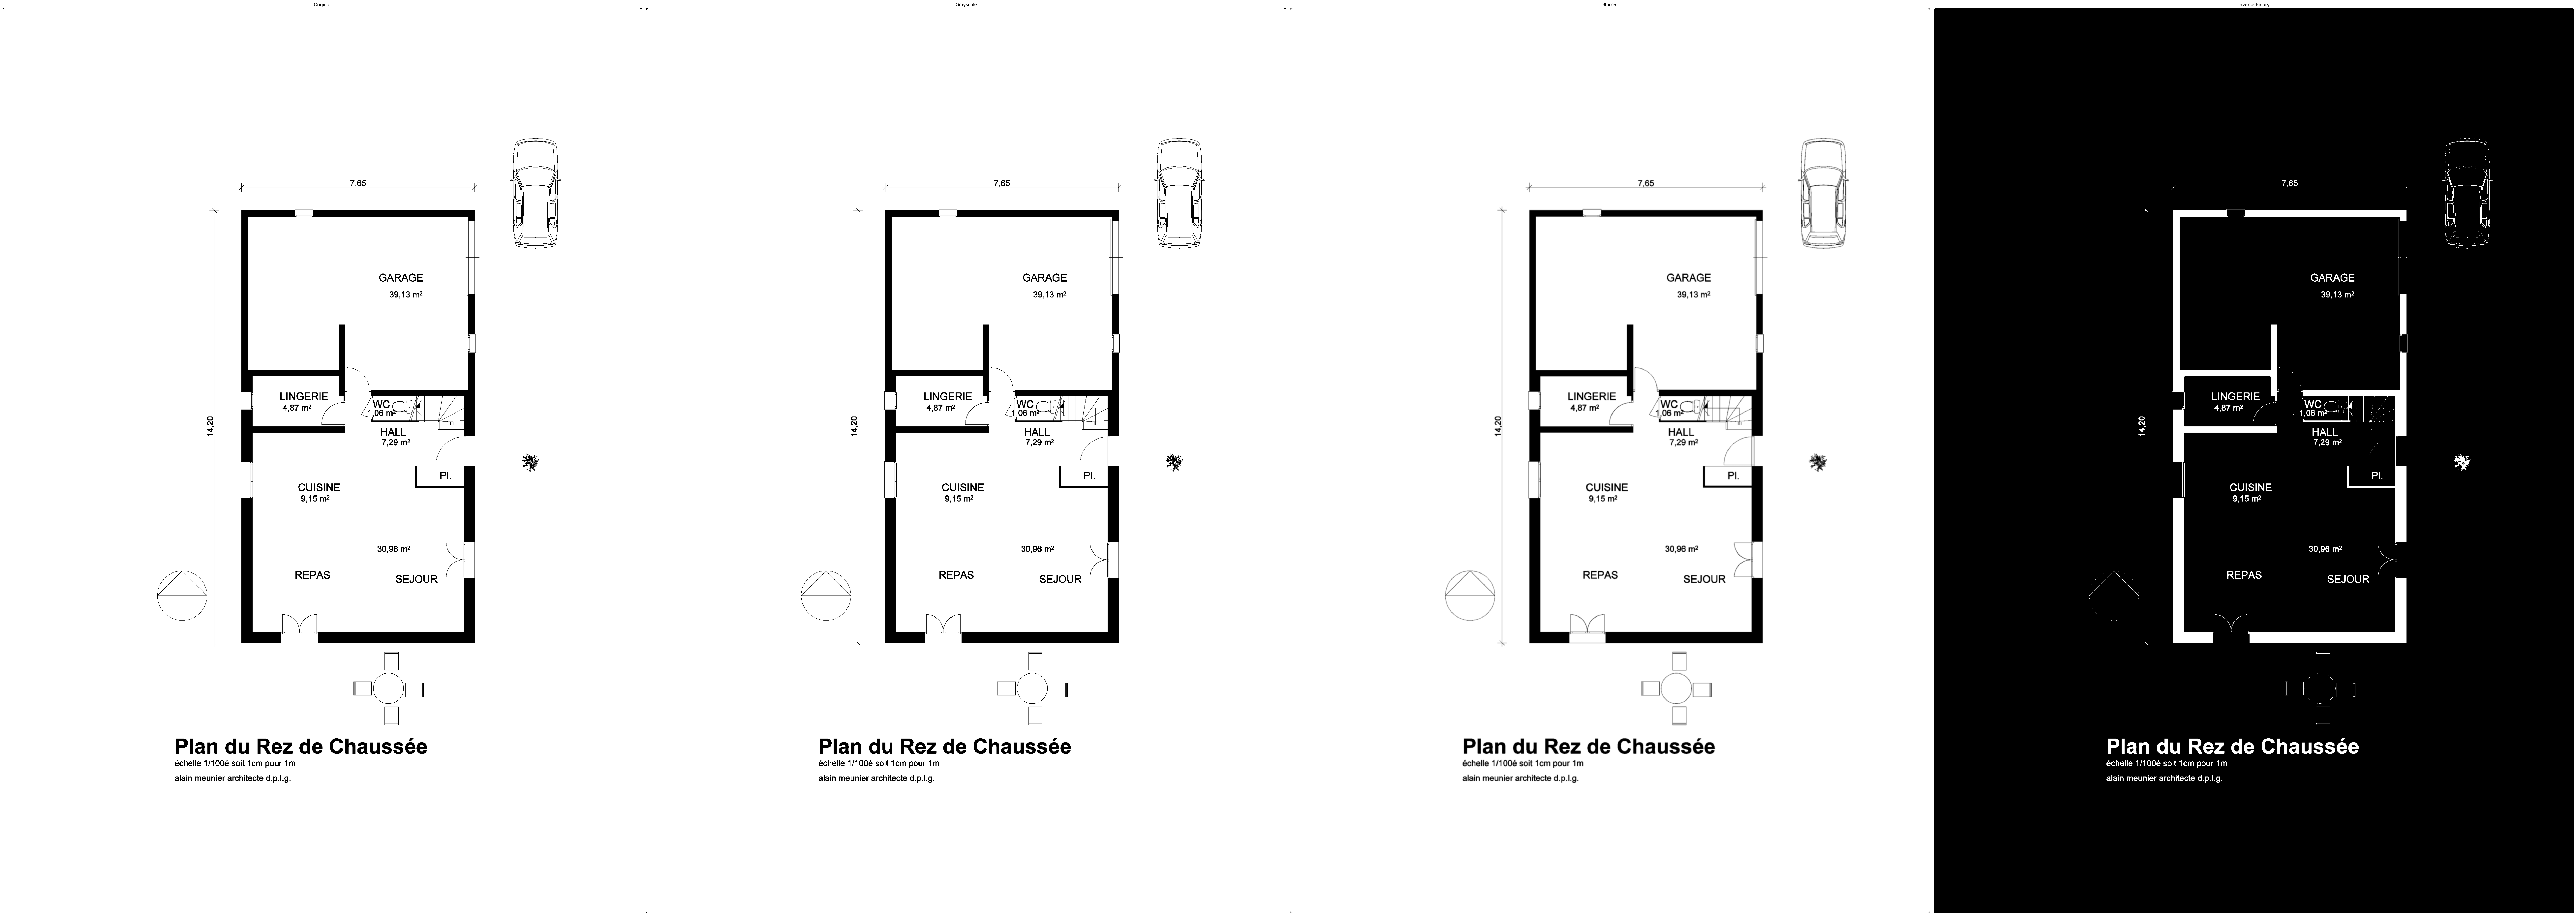

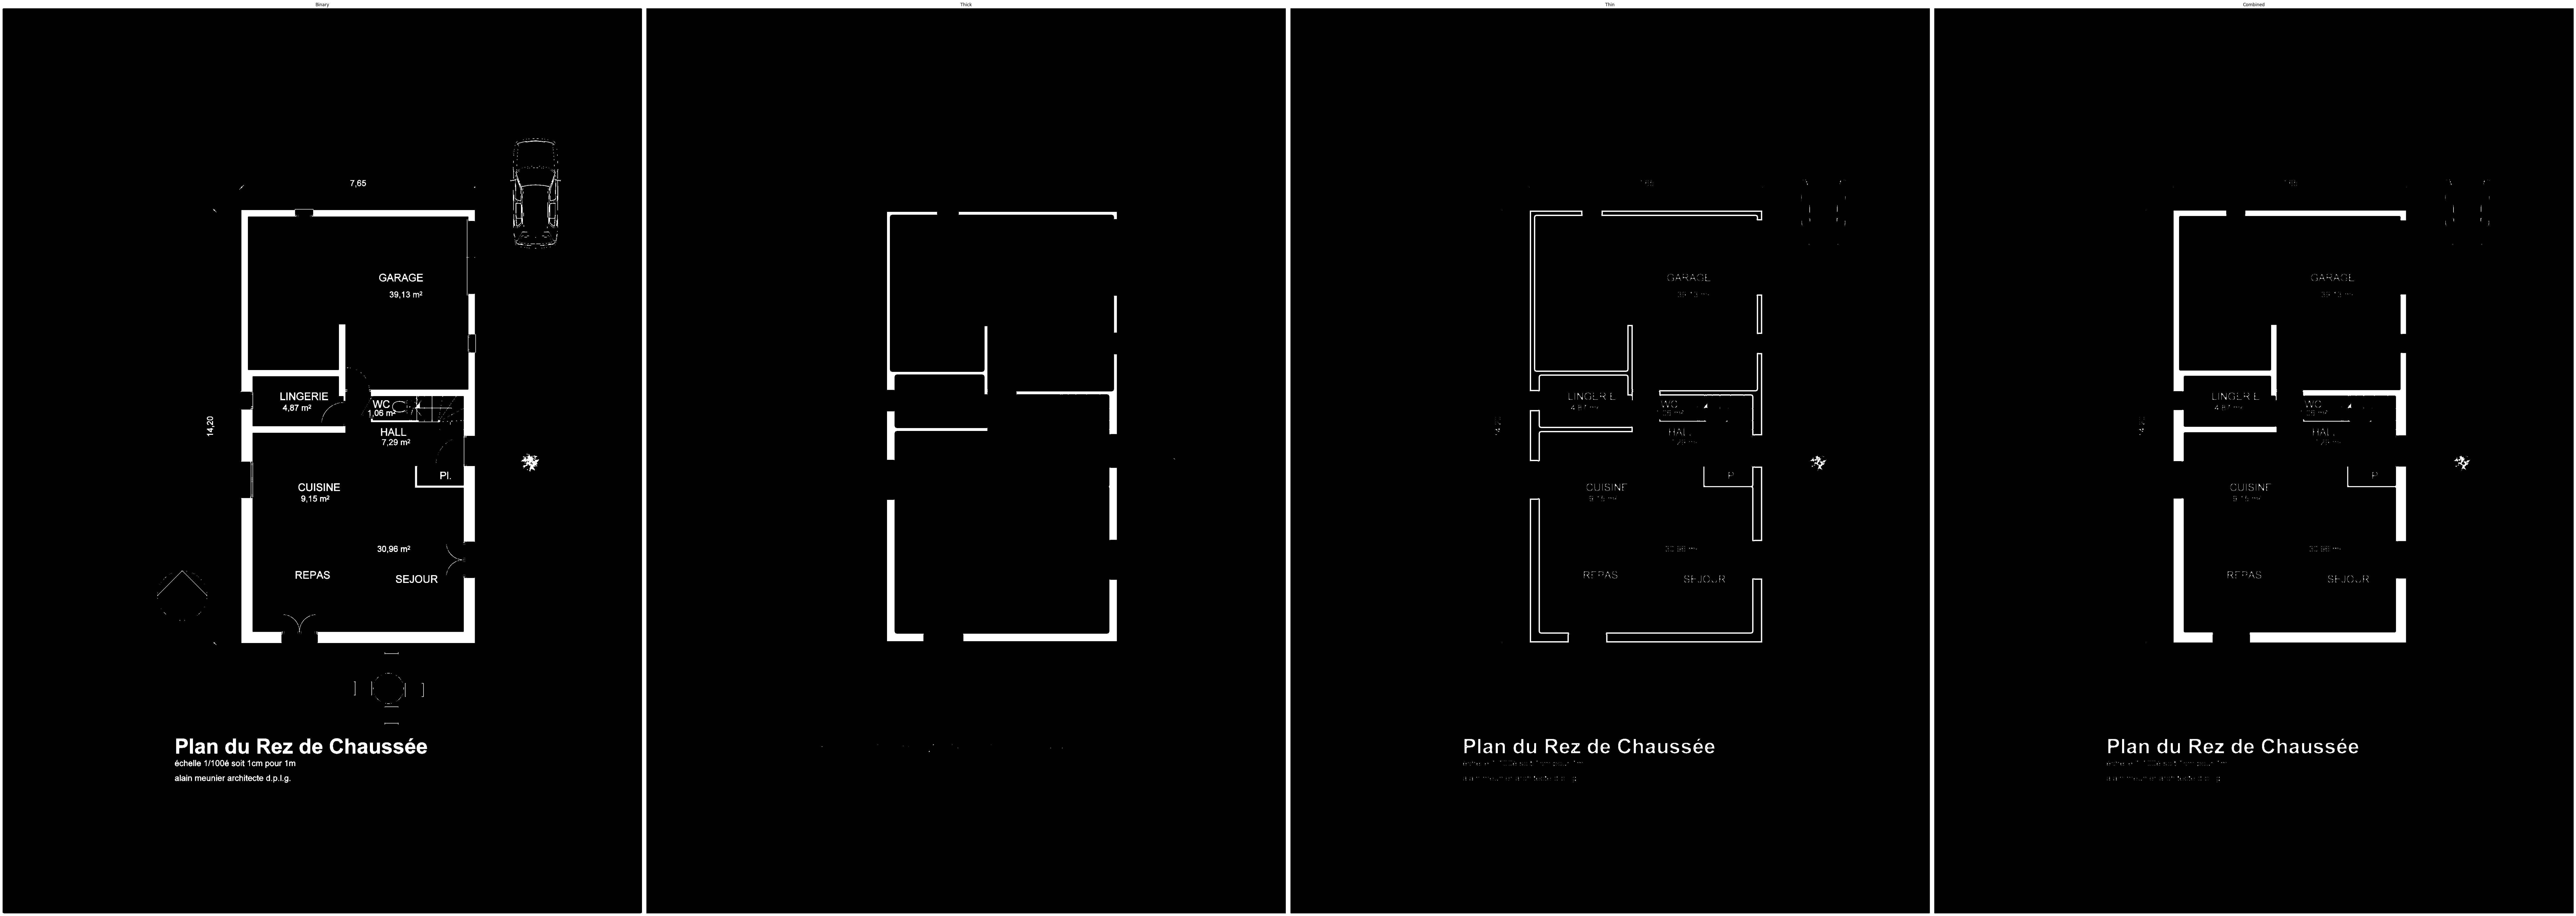

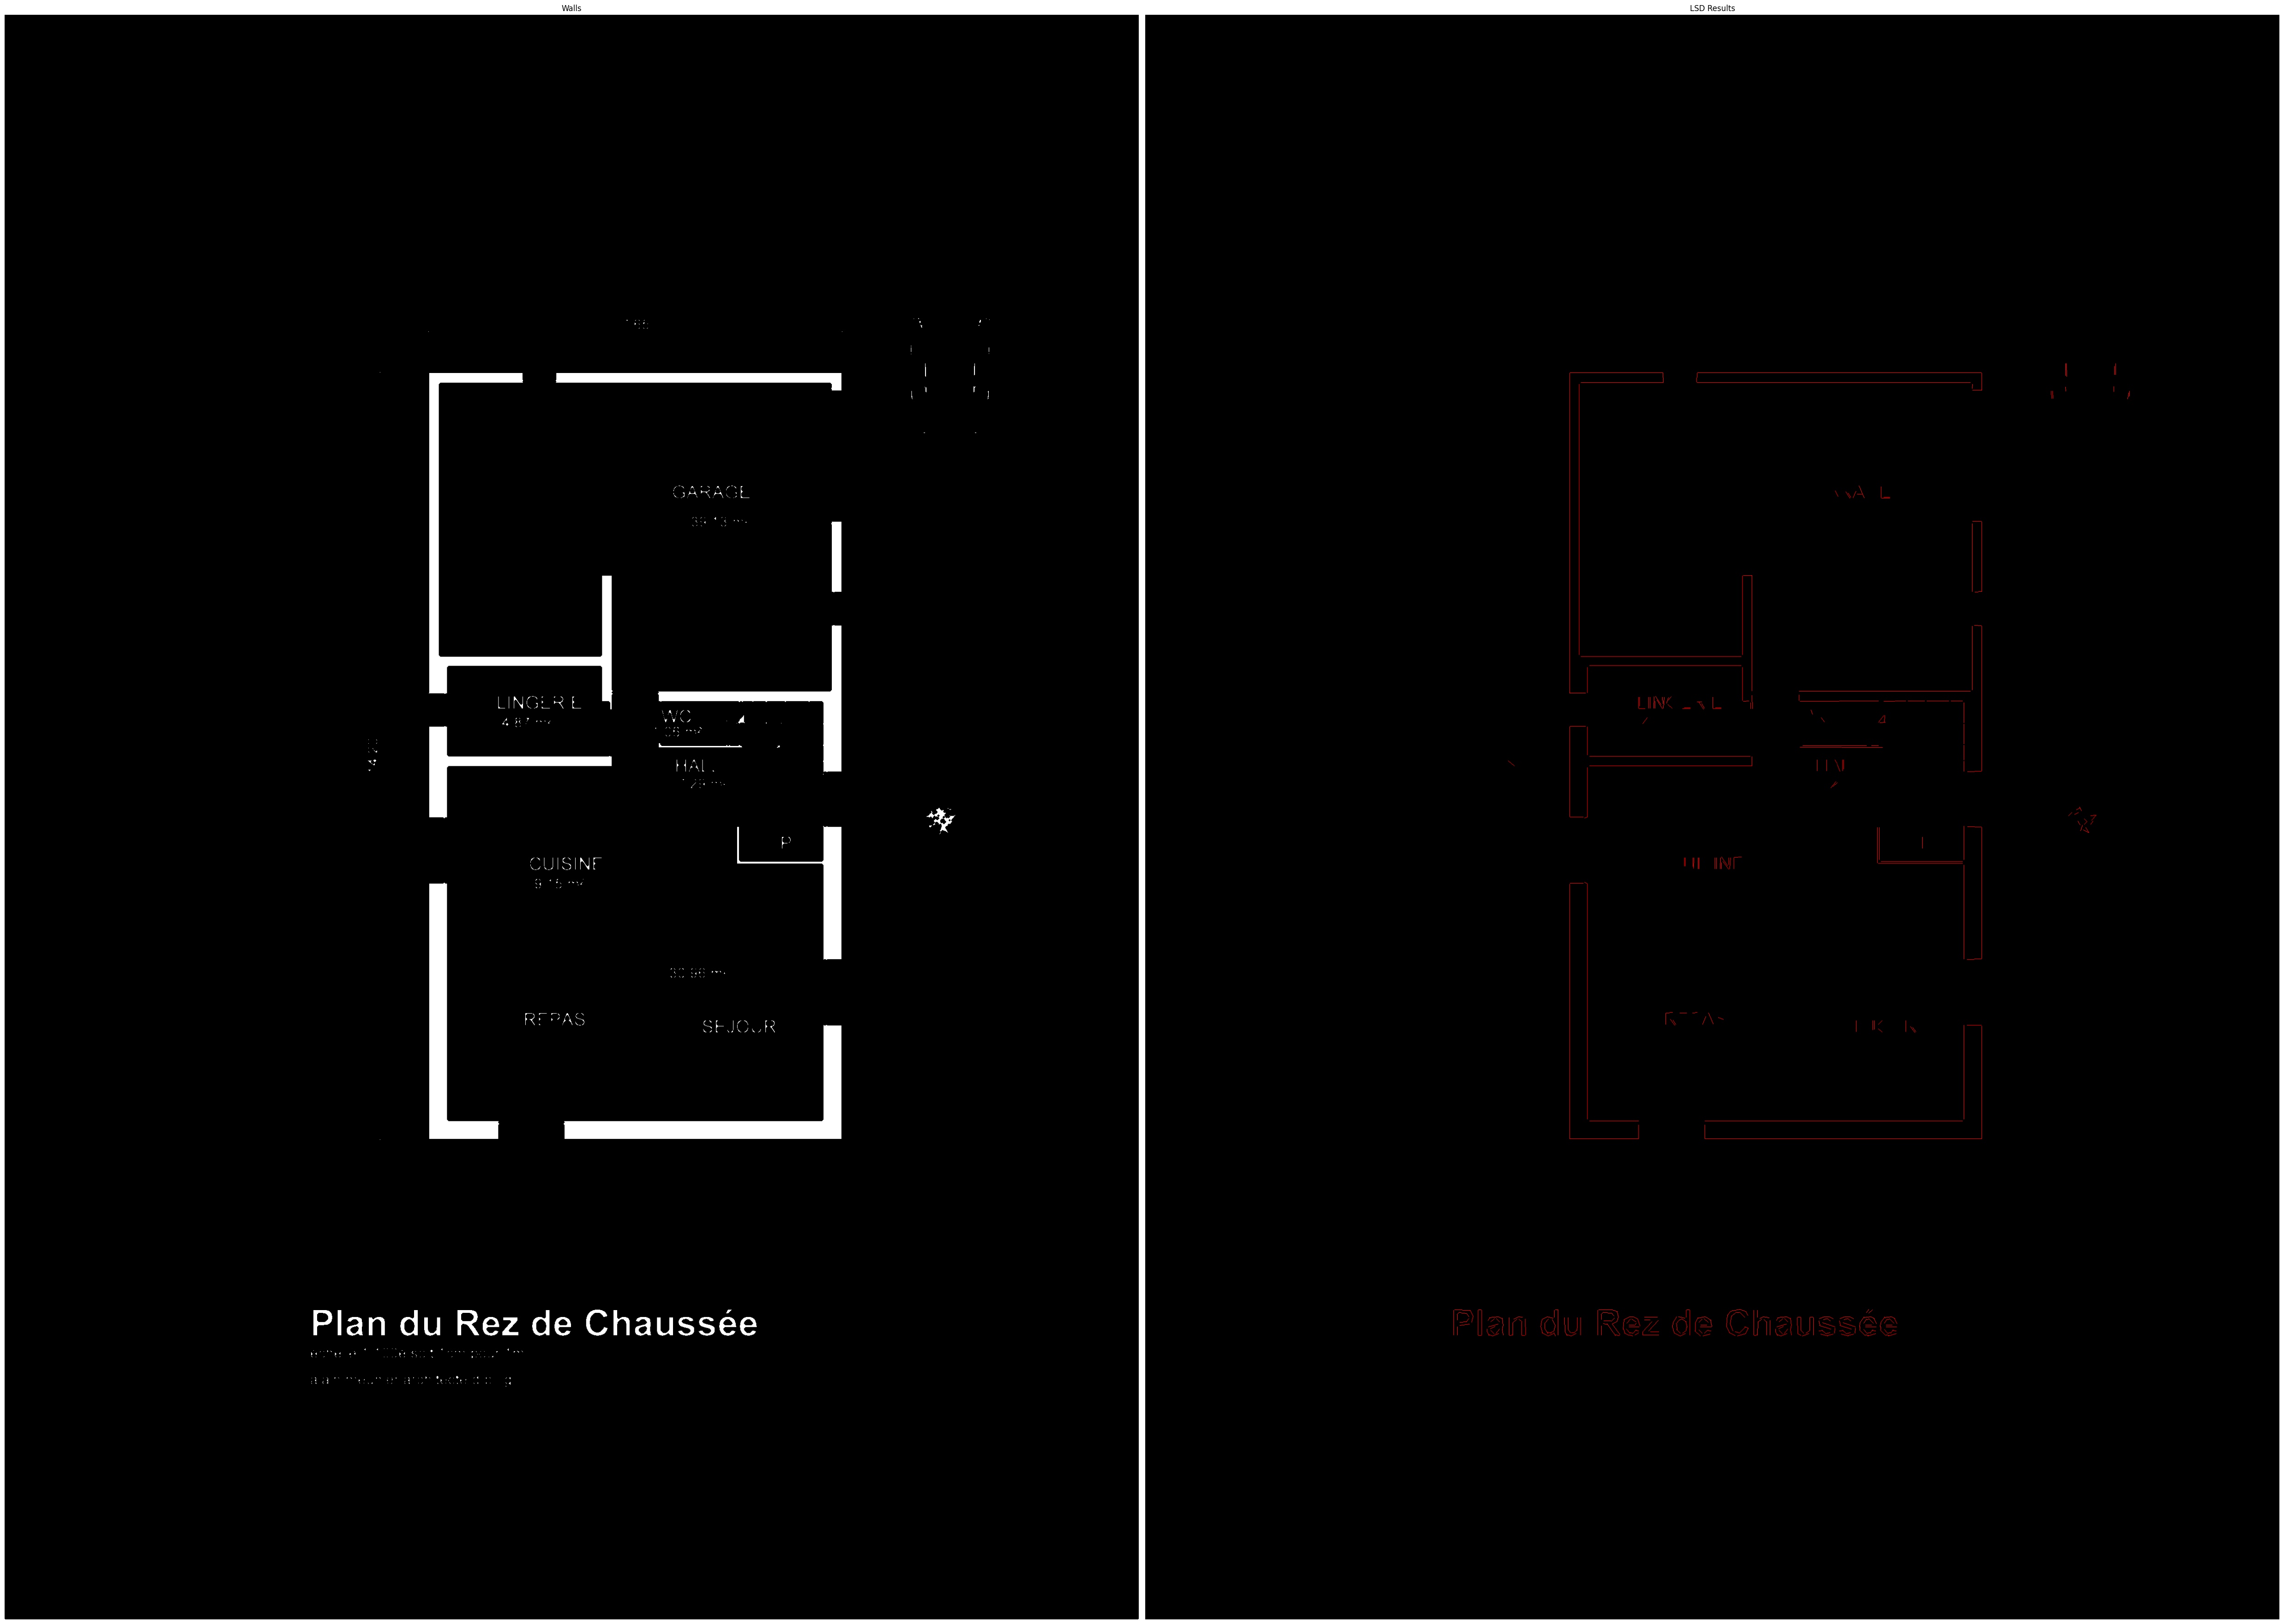

<?xml version="1.0" encoding="UTF-8"?>
<svg xmlns="http://www.w3.org/2000/svg" width="2479" height="3508" viewBox="0 0 2479 3508">
  <line x1="895" y1="2865" x2="893" y2="2876" stroke="black" stroke-width="2" />
  <line x1="951" y1="804" x2="1131" y2="804" stroke="black" stroke-width="2" />
  <line x1="1205" y1="804" x2="1803" y2="804" stroke="black" stroke-width="2" />
  <line x1="1803" y1="1479" x2="1429" y2="1479" stroke="black" stroke-width="2" />
  <line x1="1429" y1="1486" x2="1429" y2="1499" stroke="black" stroke-width="2" />
  <line x1="1789" y1="1504" x2="1789" y2="1548" stroke="black" stroke-width="2" />
  <line x1="1789" y1="1550" x2="1789" y2="1594" stroke="black" stroke-width="2" />
  <line x1="1789" y1="1596" x2="1789" y2="1629" stroke="black" stroke-width="2" />
  <line x1="1789" y1="1631" x2="1789" y2="1654" stroke="black" stroke-width="2" />
  <line x1="1796" y1="1654" x2="1826" y2="1654" stroke="black" stroke-width="2" />
  <line x1="928" y1="1754" x2="956" y2="1754" 

In [16]:
img = cv2.imread (input("Enter the path to the images to preprocess: "))
imgg = preprocess(img)
imggg = isolate_walls_multiscale(imgg)
imgggg = detect_walls_lsd(imggg)
#regularized = regularize(imgggg, img.shape[:2])
#canvas = draw_regularized(regularized, img.shape[:2])
svg = segments_to_svg(imgggg, img.shape[:2], "output.svg")


## VERIFICATION -- WALL EXTRACTION VS GROUND TRUTH (CVC-FP)

Ground-truth walls in CVC-FP are filled polygons (the wall's true footprint), while `detect_walls_lsd` outputs thin line segments approximating the *edges* of the detected wall mask, not a centerline. Comparing them exactly would fail even on a perfect detection, so a tolerance is needed -- but doing that tolerance-matching by rasterizing to a pixel mask, skeletonizing, and dilating with a square kernel (the original approach) introduces its own error: pixel-grid quantization, skeletonization artifacts, and a square structuring element standing in for a true uniform buffer. Since the actual deliverable here is vector geometry, comparison is done in **vector space** instead, with Shapely:

1. each GT `Wall` polygon in CVC-FP is an (unclosed) 4-point quad -- the wall's rectangular footprint, not a line. Its centerline is computed exactly: of the two pairs of opposite edges, the shorter pair are the wall's end caps, and the centerline is the segment joining their midpoints (`_wall_centerline`). No skeletonization needed.
2. predicted segments are used directly as line geometry (no rasterizing to a mask)
3. both the GT centerline network and the predicted line network are buffered by a tolerance `tau` (scales with image size, same convention used for other thresholds in this notebook) directly in continuous coordinates, to absorb the edge-vs-centerline offset and normal annotation noise
4. **precision / "correctness"** = fraction of predicted line *length* that lies inside the buffered GT network -- how much of what we drew is a real wall
5. **recall / "completeness"** = fraction of GT centerline *length* that lies inside the buffered predicted network -- how much of the true wall network we found
6. **F1** = harmonic mean of the two

Scoped to CVC-FP only: its SVGs map 1:1 onto their PNG's pixel grid, confirmed by checking width/height against the matching image. (CubiCasa5k's `model.svg` does not -- its `viewBox` has a different aspect ratio than either of its PNGs -- so it isn't handled here.)

In [ ]:
import xml.etree.ElementTree as ET # to parse ground-truth SVGs (stdlib, no new dependency)
import glob
from shapely.geometry import LineString # vector-space wall geometry, buffering/intersection for GT comparison
from shapely.ops import unary_union

# CVC-FP SVGs declare a default xmlns, so every tag lookup below must be namespace-qualified
# (plain root.find("polygon") silently matches nothing)
SVG_NS = {"svg": "http://www.w3.org/2000/svg"}

extract ground-truth wall geometry from a CVC-FP SVG and turn it into a mask directly comparable to the source image (coordinates match the image's pixel grid 1:1, no scaling needed)

In [ ]:
# return points of the extreme vertices of the walls in the SVG
def parse_gt_walls(svg_path):
    root = ET.parse(svg_path).getroot()

    # CVC-FP stores width/height as plain custom tags, not real svg attributes
    # here only as a sanity check that the svg/image pair actually match
    width_tag = root.find("svg:width", SVG_NS)
    height_tag = root.find("svg:height", SVG_NS)

    if width_tag is not None and height_tag is not None:
        declared_size = (int(width_tag.text), int(height_tag.text))  
    else:
        declared_size = None

    polygons = []
    for poly in root.findall("svg:polygon", SVG_NS):
        if poly.get("class") != "Wall": # consider only walls polygons
            continue
        # points = 1.123,2.345 3.456,4.567 ... -> get single points by splitting on space and then on comma
        points = [tuple(map(float, pair.split(","))) for pair in poly.get("points").split()]
        polygons.append(points)

    return polygons, declared_size

In [ ]:
# used only for the visual overlay in visualize_wall_match
def rasterize_wall_polygons(polygons, shape):
    mask = np.zeros(shape, dtype=np.uint8) # mask of 0s with the same shape as the image

    for points in polygons:
        pts = np.array(points, dtype=np.int32).reshape((-1, 1, 2)) # to have fillPoly expected shape
        cv2.fillPoly(mask, [pts], 255) # color mask with white where the polygon is filled (pts)
    return mask

In [ ]:
# return the centerline, line that joins the midpoints of the two smaller edges of the wall polygon
def wall_centerline(points):
    pts = np.array(points, dtype=float)
    n = len(pts)

    if n == 4: # should be quadrilateral, but just in case check anyway
        edges = [(pts[k], pts[(k + 1) % 4]) for k in range(4)] # store the edges (pair of consecutive vertices)
        edge_lengths = [np.sqrt((b[0] - a[0])**2 + (b[1] - a[1])**2) for a, b in edges] # compute the length of each edge

        # find the shorter pair of opposite edges
        if edge_lengths[0] + edge_lengths[2] <= edge_lengths[1] + edge_lengths[3]:
            shorter_edges = (edges[0], edges[2])
        else:
            shorter_edges = (edges[1], edges[3])

        # compute the midpoints
        centerline_start = (shorter_edges[0][0] + shorter_edges[0][1]) / 2
        centerline_end = (shorter_edges[1][0] + shorter_edges[1][1]) / 2

    else: # if the polygon is not a quadrilateral --> the two most distant vertices approximate the long axis
        # distances = [dist, i, j]
        distances = [(np.sqrt((pts[i][0] - pts[j][0])**2 + (pts[i][1] - pts[j][1])**2), i, j) for i in range(n) for j in range(i + 1, n)]
        _, i, j = max(distances) # get the indexes of the two most distant vertices (the distance is not relevant)
        centerline_start, centerline_end = pts[i], pts[j]

    return tuple(centerline_start), tuple(centerline_end)

buffer-tolerance precision/recall/F1 between predicted wall lines and the GT wall network

In [ ]:
# compute precision, recall, and F1 score (line intersection approach, not pixel by pixel)
def compute_metrics(pred_segments, gt_polygons, img_shape, tolerance=None):
    h, w = img_shape
    if tolerance is None:
        tolerance = max(3, round(0.01 * min(h, w))) # resolution-proportional

    # convert ground-truth polygons to centerline segments
    gt_lines = [LineString(wall_centerline(poly)) for poly in gt_polygons if len(poly) >= 3]

    # convert predicted segments to LineStrings, filtering out zero-length segments
    pred_lines = [LineString([(x1, y1), (x2, y2)]) for x1, y1, x2, y2 in pred_segments]

    # compute a single geometry for the entire network of walls (union of all lines)
    gt_network = unary_union(gt_lines) if gt_lines else LineString()
    pred_network = unary_union(pred_lines) if pred_lines else LineString()

    # get a geometry that represents the "tolerance zone"
    gt_with_tolerance = gt_network.buffer(tolerance)
    pred_with_tolerance = pred_network.buffer(tolerance)

    pred_total_length = sum(line.length for line in pred_lines)
    gt_total_length = sum(line.length for line in gt_lines)

    # precision = TP / (TP + FP)
    # (length of predicted walls that intersect with the ground truth tolerance zone) / (total length of predicted walls)
    precision = pred_network.intersection(gt_with_tolerance).length / pred_total_length if pred_total_length != 0 else 0.0

    # recall = TP / (TP + FN)
    # (length of ground truth walls that intersect with the predicted tolerance zone) / (total length of ground truth walls)
    recall = gt_network.intersection(pred_with_tolerance).length / gt_total_length if gt_total_length != 0 else 0.0

    # F1 score = 2 * (precision * recall) / (precision + recall)
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)        

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tolerance": tolerance
    }

In [ ]:
def visualize_wall_match(img, pred_segments, gt_mask, metrics):
    h, w = gt_mask.shape

    pred_mask = np.zeros((h, w), dtype=np.uint8)

    for x1, y1, x2, y2 in pred_segments:
        cv2.line(pred_mask, (int(x1), int(y1)), (int(x2), int(y2)), 255, 2) # thicker line just to make it visible

    # colour overlay in BGR (same convention show_images expects)
    overlay = np.zeros((h, w, 3), dtype=np.uint8)
    # overlap is "automatically" displayed as magenta (red + blue) where the two masks intersect
    overlay[..., 0] = gt_mask   # B channel
    overlay[..., 2] = pred_mask # R channel

    print(f"precision={metrics['precision']:.3f}  recall={metrics['recall']:.3f}  f1={metrics['f1']:.3f}  tolerance={metrics['tolerance']}px")

    '''show_images({
        "Original": img,
        "GT walls": gt_mask,
        "Predicted lines": pred_mask,
        "Overlay (GT=blue, Pred=red)": overlay
    })'''

single-image and batch entry points.

`_evaluate_pair` is shared by both: it runs the existing pipeline unchanged (`preprocess` -> `isolate_walls_multiscale` -> `detect_walls_lsd`) and scores the result. `preprocess`/`isolate_walls_multiscale`/`detect_walls_lsd` all call `show_images()` unconditionally -- fine for one image, but a batch run over the whole dataset would pop up hundreds of blocking figures, so `quiet=True` temporarily swaps `show_images` for a no-op for the duration of the pipeline calls, then restores it.

In [ ]:
def evaluate_pair(img_path, svg_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")

    polygons, declared_size = parse_gt_walls(svg_path)
    
    h, w = img.shape[:2]
    if declared_size is not None and declared_size != (w, h):
        raise ValueError(f"{svg_path} declares size {declared_size} but {img_path} is {(w, h)}")

    # pipeline
    binary_img = preprocess(img)
    walls_mask = isolate_walls_multiscale(binary_img)
    pred_segments = detect_walls_lsd(walls_mask)
    
    gt_mask = rasterize_wall_polygons(polygons, (h, w)) # for visualize_wall_match's overlay only
    metrics = compute_metrics(pred_segments, polygons, (h, w))

    return metrics, pred_segments, gt_mask, img

In [ ]:
# evaluate performances on a single image (works if names between original and svg are coherent)
def verify_single(img_path, svg_path=None):
    if svg_path is None:
        img_name = os.path.splitext(img_path)[0]
        svg = glob.glob(f"{img_name}_gt_*.svg") # find the correspondent (name coherence) svg
        if not svg:
            raise FileNotFoundError(f"No ground-truth SVG found for {img_path} (expected {img_name}_gt_*.svg)")
        svg_path = svg[0]

    metrics, pred_segments, gt_mask, img = evaluate_pair(img_path, svg_path, quiet=False)
    visualize_wall_match(img, pred_segments, gt_mask, metrics)

    return metrics

In [ ]:
# evaluate performances at batch level (works if names between original and svg are coherent)
def verify_dataset(images_gt_dir):
    supported_formats = (".png", ".jpg", ".jpeg")
    results = []

    # evaluate each image
    for filename in sorted(os.listdir(images_gt_dir)):
        if not filename.lower().endswith(supported_formats): # skip non supported formats
            continue

        img_path = os.path.join(images_gt_dir, filename)
        img_name = os.path.splitext(filename)[0]
        svg = glob.glob(os.path.join(images_gt_dir, f"{img_name}_gt_*.svg")) # find the correspondent svg img

        if not svg:
            print(f"skipping {filename}: no matching ground-truth SVG")
            continue

        metrics, *_ = evaluate_pair(img_path, svg[0])
        results.append({"image": filename, **metrics})

    if results:
        precisions = [r["precision"] for r in results]
        recalls = [r["recall"] for r in results]
        f1s = [r["f1"] for r in results]
        print(f"\nevaluated {len(results)} images")
        print(f"precision: mean={np.mean(precisions):.3f} median={np.median(precisions):.3f}")
        print(f"recall:    mean={np.mean(recalls):.3f} median={np.median(recalls):.3f}")
        print(f"f1:        mean={np.mean(f1s):.3f} median={np.median(f1s):.3f}")

    return results

## PERFORMANCE TRACKING & GRAPHS

`verify_dataset`/`verify_single` above compute precision/recall/F1 but only print them -- the numbers are gone as soon as the pipeline or a parameter changes and the cell reruns. This section saves a graph + a short text description of which pipeline/parameters produced it to `GRAPHS/` every time an evaluation is run, plus a history log so runs can be compared over time (e.g. before/after tuning `isolate_walls_multiscale`'s thresholds, or switching Hough vs LSD).

`GRAPHS/` is tracked in git, so performance history is visible across commits.

In [ ]:
from datetime import datetime
import json
import re
import textwrap

GRAPHS_DIR = "GRAPHS"

# fixed categorical color per metric
METRIC_COLORS = {"precision": "#2a78d6", "recall": "#eb6834", "f1": "#1baf7a"}
CHART_SURFACE = "#fcfcfb"
CHART_INK = "#0b0b0b"
CHART_MUTED = "#898781"
CHART_GRID = "#e1e0d9"

In [ ]:
def log_performance(results, tag, description, output_dir=GRAPHS_DIR):
    # accept list of results or a single result dict
    if isinstance(results, dict):
        results = [results]

    os.makedirs(output_dir, exist_ok=True)

    '''aggregate = { 
        "precision": { "mean": 0.8, "median": 0.8 },
        "recall": { "mean": 0.7, median": 0.7 },
        "f1": { "mean": 0.746, "median": 0.746 }
    }'''
    aggregate = {
        metric: {"mean": float(np.mean([r[metric] for r in results])), "median": float(np.median([r[metric] for r in results]))}
        for metric in METRIC_COLORS
    }

    # create a unique run ID based on timestamp and tag, to avoid overwriting previous runs
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S") #yearmonthday-hourminutesecond
    safe_tag = re.sub(r"[^a-zA-Z0-9_-]+", "-", tag).strip("-") or "run"
    run_id = f"{timestamp}_{safe_tag}"

    fig, ax_x = plt.subplots(figsize=(6, 4.5), facecolor=CHART_SURFACE)

    # mean vs median for each metric graph
    ax_x.set_facecolor(CHART_SURFACE)
    x = np.arange(len(METRIC_COLORS))   
    width = 0.32

    # plot mean values first, median values then
    for offset, stat, hatch in [(-1, "mean", None), (1, "median", "///")]: # offset = to not overlap mean and median graphs, hatch = graph pattern
        heights = [aggregate[m][stat] for m in METRIC_COLORS] # value of each stat for the given metric
        # bar style
        bars = ax_x.bar(x + offset * width / 2, heights, width,
                           color=list(METRIC_COLORS.values()), hatch=hatch,
                           edgecolor=CHART_SURFACE, linewidth=1)
        # numbers above each bar
        for rect, h in zip(bars, heights):
            ax_x.text(rect.get_x() + rect.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center", va="bottom", fontsize=8, color=CHART_INK)

    # style graph    
    ax_x.set_xticks(x)
    ax_x.set_xticklabels([m.capitalize() for m in METRIC_COLORS], color=CHART_INK)
    ax_x.set_ylim(0, 1.12) # room for the numbers above the bars
    ax_x.set_ylabel("score", color=CHART_MUTED)
    ax_x.tick_params(colors=CHART_MUTED)
    ax_x.yaxis.grid(True, color=CHART_GRID, linewidth=0.8) # add horizontal grid lines to the graph
    ax_x.set_axisbelow(True)

    # remove/modify spines (borders) of the graph
    for spine in ("top", "right"):
        ax_x.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax_x.spines[spine].set_color(CHART_GRID)

    # legend
    mean_patch = plt.Rectangle((0, 0), 1, 1, facecolor=CHART_MUTED, edgecolor=CHART_SURFACE)
    median_patch = plt.Rectangle((0, 0), 1, 1, facecolor=CHART_MUTED, edgecolor=CHART_SURFACE, hatch="///")
    ax_x.legend([mean_patch, median_patch], ["mean", "median"], frameon=False, loc="upper right", fontsize=8, labelcolor=CHART_INK)
    ax_x.set_title(f"{len(results)} image{'s' if len(results) != 1 else ''} evaluated", fontsize=10, color=CHART_MUTED, loc="left")

    fig.suptitle(tag, fontsize=13, color=CHART_INK, fontweight="bold", x=0.02, y=0.99, ha="left") # title of the run, top-left
    fig.text(0.02, 0.905, timestamp, fontsize=9, color=CHART_MUTED, ha="left") # add the ID to the title

    wrapped_description = "\n".join(textwrap.wrap(description, width=140)) if description else ""
    if wrapped_description:
        fig.text(0.02, 0.04, wrapped_description, fontsize=8, color=CHART_MUTED, ha="left", va="bottom") # description

    plt.tight_layout(rect=[0, 0.12, 1, 0.88])

    summary_path = os.path.join(output_dir, f"{run_id}_summary.png") # name of the final file of the graph
    fig.savefig(summary_path, dpi=150, facecolor=CHART_SURFACE, bbox_inches="tight")
    plt.show()

    # create JSON record for the graph
    metadata = {
        "run_id": run_id,
        "tag": tag,
        "description": description,
        "timestamp": timestamp,
        "n_images": len(results),
        "aggregate": aggregate,
        "per_image": results,
    }
    with open(os.path.join(output_dir, f"{run_id}_metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)

    # add to the JSON storing the history of all runs
    history_path = os.path.join(output_dir, "history.json")
    history = []
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
    history.append({
        "run_id": run_id,
        "tag": tag,
        "description": description,
        "timestamp": timestamp,
        "n_images": len(results),
        "aggregate": aggregate,
    })
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    print(f"saved {summary_path}")
    return metadata

In [ ]:
def plot_history(output_dir=GRAPHS_DIR):
    history_path = os.path.join(output_dir, "history.json")
    if not os.path.exists(history_path):
        print(f"no history in {history_path} yet, call log_performance() at least once")
        return

    with open(history_path) as f:
        history = json.load(f)
    if not history:
        print("history.json is empty")
        return

    tags = [run["tag"] for run in history] # get tags of the runs
    x = np.arange(len(history))

    fig, ax = plt.subplots(figsize=(max(6, len(history) * 0.9), 4.5), facecolor=CHART_SURFACE) # width proportional to #runs
    ax.set_facecolor(CHART_SURFACE)

    # plot means of each metric
    for metric, color in METRIC_COLORS.items():
        values = [run["aggregate"][metric]["mean"] for run in history]
        ax.plot(x, values, marker="o", markersize=6, linewidth=2, color=color, label=metric.capitalize())

    # style graph
    ax.set_xticks(x)
    ax.set_xticklabels(tags, rotation=45, ha="right", color=CHART_INK, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("mean score", color=CHART_MUTED)
    ax.tick_params(colors=CHART_MUTED)
    ax.yaxis.grid(True, color=CHART_GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    # remove/modify spines (borders) of the graph
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(CHART_GRID)

    # legend
    ax.legend(frameon=False, loc="lower right", labelcolor=CHART_INK)
    ax.set_title("performance across pipeline runs", fontsize=12, color=CHART_INK, loc="left", fontweight="bold")

    plt.tight_layout()
    trend_path = os.path.join(output_dir, "history_trend.png")
    fig.savefig(trend_path, dpi=150, facecolor=CHART_SURFACE, bbox_inches="tight")
    plt.show()

    print(f"saved {trend_path}")
    return history

Usage: run an evaluation, then log it with a short `tag` (used as the x-axis label in the history trend) and a `description` naming the pipeline/parameters that produced it.

```python
results = verify_dataset("DATASETS/CVC-FP/ImagesGT")
log_performance(results, tag="lsd-baseline", description="preprocess + isolate_walls_multiscale(thick=7,thin=2) + detect_walls_lsd, no regularize")
plot_history()
```

Repeat with a new `tag` after changing a parameter or swapping a pipeline stage (e.g. `tag="thick9"` after raising the thick-wall threshold) to compare against past runs in `GRAPHS/history_trend.png`.